<a href="https://colab.research.google.com/github/2Jay-bi/Healthcare-No-Show-PowerBI/blob/main/Healthcare_No_Show_Model_Preparation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [ ]:
uploaded = files.upload()


Saving Healthcare_Dataset.xlsx to Healthcare_Dataset.xlsx


In [ ]:
print(uploaded.keys())

dict_keys(['Healthcare_Dataset.xlsx'])


In [ ]:
file_path = "/content/Healthcare_Dataset.xlsx"

excel_file = pd.ExcelFile(file_path)

print("Workbook sheets:")
print(excel_file.sheet_names)

Workbook sheets:
['START HERE', 'Raw_Encounters', 'Raw_Providers', 'Raw_Facilities', 'Data_Dictionary', 'ETL_Challenge_List', 'Diagnosis_Codebook', 'Sources_and_Licensing']


In [ ]:
encounters_raw = pd.read_excel(
    file_path,
    sheet_name="Raw_Encounters"
)

providers_raw = pd.read_excel(
    file_path,
    sheet_name="Raw_Providers"
)

facilities_raw = pd.read_excel(
    file_path,
    sheet_name="Raw_Facilities"
)

diagnosis_raw = pd.read_excel(
    file_path,
    sheet_name="Diagnosis_Codebook"
)

print("Encounters:", encounters_raw.shape)
print("Providers:", providers_raw.shape)
print("Facilities:", facilities_raw.shape)
print("Diagnosis codes:", diagnosis_raw.shape)

Encounters: (10018, 25)
Providers: (121, 8)
Facilities: (26, 12)
Diagnosis codes: (12, 2)


In [ ]:
encounters = encounters_raw.copy()
providers = providers_raw.copy()
facilities = facilities_raw.copy()
diagnosis = diagnosis_raw.copy()

print("Working copies created.")

Working copies created.


In [ ]:
display(encounters.head())

,Encounter_ID,Encounter_Date,Synthetic_Patient_ID,Age,Sex,Race_Ethnicity,Facility_ID,Provider_ID,Visit_Type,Visit_Mode,Primary_Diagnosis_Code,Diagnosis_Description,Payer,Scheduled_Minutes,Wait_Time_Minutes,Visit_Duration_Minutes,Charge_Amount,Allowed_Amount,No_Show_Flag,Readmission_30Day_Flag,Outcome,Follow_Up_Days,Transportation_Barrier,Food_Insecurity_Flag,Patient_Satisfaction
0,ENC-000001,2025-12-14,PAT-000926,70,M,Hispanic or Latino,FAC-005,PRV-0105,Urgent Care,Home Visit,F41.9,Anxiety disorder,Medicaid,60,64,39,589.67,525.30,No,N,Left Before Seen,NaN,No,N,5.0
1,ENC-000002,2024-09-16,PAT-000740,25,U,NaN,FAC-018,PRV-0115,Preventive Visit,Telehealth,F32.A,Depression,Medicaid,20,90,31,567.19,355.87,No,Y,Discharged,NaN,Y,N,4.0
2,ENC-000003,2025-11-30,PAT-001302,77,Female,NaN,FAC-006,PRV-0093,Preventive Visit,Telehealth,Z00.00,General adult medical examination,Medicare,30,30,31,996.98,739.65,No,N,Referred,NaN,No,N,5.0
3,ENC-000004,2024-11-04,PAT-002478,62,Male,White,FAC-004,PRV-0110,Primary Care,In Person,J06.9,Acute upper respiratory infection,Other,30,28,64,981.63,850.43,No,N,Left Before Seen,NaN,No,N,3.0
4,ENC-000005,2024-03-18,PAT-000592,53,F,Hispanic or Latino,FAC-014,PRV-0023,Urgent Care,Home Visit,Z00.00,General adult medical examination,CHIP,15,36,73,196.76,123.12,No,N,Referred,NaN,No,N,1.0


In [ ]:
display(providers.head())

,Provider_ID,Provider_Name,Specialty,Primary_Facility_ID,Credential,Employment_Status,FTE,Start_Date
0,PRV-0001,DAKOTA WALKER 1,neurology,FAC-012,MD,active,78%,4/1/21
1,PRV-0002,Rowan Jackson 2,Endocrinology,FAC-022,MD,Active,0.52,43497
2,PRV-0003,Skyler Martinez 3,Family Medicine,FAC-015,LCSW,Active,0.92,43344
3,PRV-0004,Morgan Clark 4,Obstetrics,FAC-019,LCSW,Active,0.9,44440
4,PRV-0005,Taylor Davis 5,Pediatrics,FAC-001,RN,Active,0.93,43405


In [ ]:
display(facilities.head())

,Facility_ID,Facility_Name,Facility_Type,City,State,ZIP_Code,County,Latitude,Longitude,Licensed_Beds,CMS_Style_Rating,Open_Date
0,fac-001,Community Health Center 1,HOSPITAL,FORT WORTH,TX.,76102,Tarrant,NaN,-97.3308,125 beds,2 stars,8/1/08
1,FAC-002,Community Health Center 2,Hospital,Dallas,TX,75201,Dallas,32.7767,-96.7970,163,4,38504
2,FAC-003,Community Health Center 3,Outpatient Clinic,Arlington,TX,76010,Tarrant,32.7357,-97.1081,36,3,39052
3,FAC-004,Community Health Center 4,Behavioral Health Center,Austin,TX,78701,Travis,30.2672,-97.7431,195,2,43770
4,FAC-005,Community Health Center 5,Community Health Center,Houston,TX,77002,Harris,29.7604,-95.3698,209,1,40725


In [ ]:
print("ENCOUNTER DATA TYPES")
print(encounters.dtypes)

ENCOUNTER DATA TYPES
Encounter_ID               object
Encounter_Date             object
Synthetic_Patient_ID       object
Age                        object
Sex                        object
Race_Ethnicity             object
Facility_ID                object
Provider_ID                object
Visit_Type                 object
Visit_Mode                 object
Primary_Diagnosis_Code     object
Diagnosis_Description      object
Payer                      object
Scheduled_Minutes           int64
Wait_Time_Minutes          object
Visit_Duration_Minutes      int64
Charge_Amount              object
Allowed_Amount            float64
No_Show_Flag               object
Readmission_30Day_Flag     object
Outcome                    object
Follow_Up_Days            float64
Transportation_Barrier     object
Food_Insecurity_Flag       object
Patient_Satisfaction      float64
dtype: object


In [ ]:
def data_quality_summary(dataframe, table_name):
    summary = pd.DataFrame({
        "Column": dataframe.columns,
        "Data_Type": dataframe.dtypes.astype(str).values,
        "Missing_Values": dataframe.isnull().sum().values,
        "Missing_Percent": (
            dataframe.isnull().mean().values * 100
        ).round(2),
        "Unique_Values": dataframe.nunique(dropna=True).values
    })

    print(f"{table_name}: {dataframe.shape[0]:,} rows")
    return summary

In [ ]:
encounter_quality = data_quality_summary(
    encounters,
    "Raw Encounters"
)

display(encounter_quality)

Raw Encounters: 10,018 rows


,Column,Data_Type,Missing_Values,Missing_Percent,Unique_Values
0,Encounter_ID,object,0,0.00,10000
1,Encounter_Date,object,0,0.00,1471
2,Synthetic_Patient_ID,object,0,0.00,3811
3,Age,object,0,0.00,89
4,Sex,object,0,0.00,5
5,Race_Ethnicity,object,1466,14.63,6
6,Facility_ID,object,0,0.00,44
7,Provider_ID,object,0,0.00,121
8,Visit_Type,object,0,0.00,9
9,Visit_Mode,object,0,0.00,4


In [ ]:
display(data_quality_summary(providers, "Raw Providers"))
display(data_quality_summary(facilities, "Raw Facilities"))

Raw Providers: 121 rows


,Column,Data_Type,Missing_Values,Missing_Percent,Unique_Values
0,Provider_ID,object,0,0.0,120
1,Provider_Name,object,0,0.0,120
2,Specialty,object,0,0.0,14
3,Primary_Facility_ID,object,0,0.0,25
4,Credential,object,0,0.0,7
5,Employment_Status,object,0,0.0,3
6,FTE,object,0,0.0,49
7,Start_Date,object,0,0.0,75


Raw Facilities: 26 rows


,Column,Data_Type,Missing_Values,Missing_Percent,Unique_Values
0,Facility_ID,object,0,0.00,25
1,Facility_Name,object,0,0.00,25
2,Facility_Type,object,0,0.00,8
3,City,object,0,0.00,25
4,State,object,0,0.00,21
5,ZIP_Code,int64,0,0.00,25
6,County,object,0,0.00,24
7,Latitude,float64,2,7.69,23
8,Longitude,float64,0,0.00,25
9,Licensed_Beds,object,0,0.00,22


In [ ]:
print(
    "Duplicate encounter rows:",
    encounters.duplicated().sum()
)

print(
    "Duplicate provider rows:",
    providers.duplicated().sum()
)

print(
    "Duplicate facility rows:",
    facilities.duplicated().sum()
)

Duplicate encounter rows: 18
Duplicate provider rows: 1
Duplicate facility rows: 1


In [ ]:
print(
    "Duplicate Encounter IDs:",
    encounters["Encounter_ID"].duplicated().sum()
)

print(
    "Duplicate Provider IDs:",
    providers["Provider_ID"].duplicated().sum()
)

print(
    "Duplicate Facility IDs:",
    facilities["Facility_ID"].duplicated().sum()
)

Duplicate Encounter IDs: 18
Duplicate Provider IDs: 1
Duplicate Facility IDs: 1


In [ ]:
encounters = encounters.drop_duplicates(
    subset="Encounter_ID",
    keep="first"
).copy()

providers = providers.drop_duplicates(
    subset="Provider_ID",
    keep="first"
).copy()

facilities = facilities.drop_duplicates(
    subset="Facility_ID",
    keep="first"
).copy()

print("Clean encounter rows:", len(encounters))
print("Clean provider rows:", len(providers))
print("Clean facility rows:", len(facilities))

Clean encounter rows: 10000
Clean provider rows: 120
Clean facility rows: 25


In [ ]:
def clean_column_names(dataframe):
    dataframe.columns = (
        dataframe.columns
        .str.strip()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
    )

    return dataframe


In [ ]:
encounters = clean_column_names(encounters)
providers = clean_column_names(providers)
facilities = clean_column_names(facilities)
diagnosis = clean_column_names(diagnosis)

In [ ]:
encounter_keys = [
    "Encounter_ID",
    "Synthetic_Patient_ID",
    "Facility_ID",
    "Provider_ID"
]

for column in encounter_keys:
    encounters[column] = (
        encounters[column]
        .astype("string")
        .str.strip()
        .str.upper()
    )

In [ ]:
providers["Provider_ID"] = (
    providers["Provider_ID"]
    .astype("string")
    .str.strip()
    .str.upper()
)

providers["Primary_Facility_ID"] = (
    providers["Primary_Facility_ID"]
    .astype("string")
    .str.strip()
    .str.upper()
)

In [ ]:
facilities["Facility_ID"] = (
    facilities["Facility_ID"]
    .astype("string")
    .str.strip()
    .str.upper()
)

In [ ]:
print(encounters["No_Show_Flag"].value_counts(dropna=False))

No_Show_Flag
No     9202
Y       791
yes       7
Name: count, dtype: int64


In [ ]:
no_show_mapping = {
    "Y": 1,
    "YES": 1,
    "TRUE": 1,
    "1": 1,
    "N": 0,
    "NO": 0,
    "FALSE": 0,
    "0": 0
}

encounters["No_Show_Target"] = (
    encounters["No_Show_Flag"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map(no_show_mapping)
)

In [ ]:
print(
    encounters["No_Show_Target"]
    .value_counts(dropna=False)
)

print(
    encounters["No_Show_Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

No_Show_Target
0    9202
1     798
Name: count, dtype: int64
No_Show_Target
0    92.02
1     7.98
Name: proportion, dtype: float64


In [ ]:
encounters["Appointment_Status"] = np.where(
    encounters["No_Show_Target"] == 1,
    "No-Show",
    "Attended"
)

In [ ]:
def clean_text_column(series):
    return (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

In [ ]:
categorical_columns = [
    "Sex",
    "Race_Ethnicity",
    "Visit_Type",
    "Visit_Mode",
    "Primary_Diagnosis_Code",
    "Diagnosis_Description",
    "Payer",
    "Outcome",
    "Transportation_Barrier",
    "Food_Insecurity_Flag"
]

for column in categorical_columns:
    encounters[column] = clean_text_column(
        encounters[column]
    )

In [ ]:
print(encounters["Sex"].value_counts(dropna=False))

Sex
MALE      2052
F         2010
U         1994
FEMALE    1977
M         1967
Name: count, dtype: Int64


In [ ]:
sex_mapping = {
    "M": "MALE",
    "MALE": "MALE",
    "F": "FEMALE",
    "FEMALE": "FEMALE",
    "U": "UNKNOWN",
    "UNKNOWN": "UNKNOWN"
}

encounters["Sex"] = (
    encounters["Sex"]
    .replace(sex_mapping)
    .fillna("UNKNOWN")
)

In [ ]:
print(encounters["Sex"].value_counts())

Sex
MALE       4019
FEMALE     3987
UNKNOWN    1994
Name: count, dtype: Int64


In [ ]:
encounters["Visit_Type"] = (
    encounters["Visit_Type"]
    .replace({
        "FOLLOW UP": "FOLLOW-UP"
    })
)

encounters["Visit_Mode"] = (
    encounters["Visit_Mode"]
    .replace({
        "TELE-HEALTH": "TELEHEALTH",
        "IN-PERSON": "IN PERSON"
    })
)

In [ ]:
print(encounters["Visit_Type"].value_counts())
print(encounters["Visit_Mode"].value_counts())

Visit_Type
FOLLOW-UP             1304
PRIMARY CARE          1268
URGENT CARE           1262
SPECIALIST CONSULT    1260
CARE COORDINATION     1233
BEHAVIORAL HEALTH     1230
PREVENTIVE VISIT      1224
TELEHEALTH            1219
Name: count, dtype: Int64
Visit_Mode
IN PERSON     3400
TELEHEALTH    3311
HOME VISIT    3289
Name: count, dtype: Int64


In [ ]:
yes_no_mapping = {
    "Y": "YES",
    "YES": "YES",
    "TRUE": "YES",
    "1": "YES",
    "N": "NO",
    "NO": "NO",
    "FALSE": "NO",
    "0": "NO"
}

In [ ]:
yes_no_columns = [
    "Transportation_Barrier",
    "Food_Insecurity_Flag",
    "Readmission_30Day_Flag"
]

for column in yes_no_columns:
    encounters[column] = (
        encounters[column]
        .replace(yes_no_mapping)
    )

In [ ]:
for column in yes_no_columns:
    print(f"\n{column}")
    print(encounters[column].value_counts(dropna=False))


Transportation_Barrier
Transportation_Barrier
NO     8791
YES    1209
Name: count, dtype: Int64

Food_Insecurity_Flag
Food_Insecurity_Flag
NO     9019
YES     981
Name: count, dtype: Int64

Readmission_30Day_Flag
Readmission_30Day_Flag
NO     9098
YES     902
Name: count, dtype: int64


In [ ]:
numeric_columns = [
    "Age",
    "Scheduled_Minutes",
    "Wait_Time_Minutes",
    "Visit_Duration_Minutes",
    "Charge_Amount",
    "Allowed_Amount",
    "Follow_Up_Days",
    "Patient_Satisfaction"
]

In [ ]:
for column in numeric_columns:
    encounters[column] = (
        encounters[column]
        .astype("string")
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("MINUTES", "", regex=False)
        .str.strip()
    )

    encounters[column] = pd.to_numeric(
        encounters[column],
        errors="coerce"
    )

In [ ]:
print(encounters[numeric_columns].dtypes)

Age                         Int64
Scheduled_Minutes           Int64
Wait_Time_Minutes           Int64
Visit_Duration_Minutes      Int64
Charge_Amount             Float64
Allowed_Amount            Float64
Follow_Up_Days            Float64
Patient_Satisfaction      Float64
dtype: object


In [ ]:
def convert_mixed_dates(series):
    text_dates = pd.to_datetime(
        series,
        errors="coerce"
    )

    numeric_dates = pd.to_numeric(
        series,
        errors="coerce"
    )

    excel_dates = pd.to_datetime(
        numeric_dates,
        unit="D",
        origin="1899-12-30",
        errors="coerce"
    )

    return text_dates.fillna(excel_dates)

In [ ]:
encounters["Encounter_Date"] = convert_mixed_dates(
    encounters["Encounter_Date"]
)

providers["Start_Date"] = convert_mixed_dates(
    providers["Start_Date"]
)

facilities["Open_Date"] = convert_mixed_dates(
    facilities["Open_Date"]
)

/tmp/ipykernel_1753/4207873398.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  text_dates = pd.to_datetime(
/tmp/ipykernel_1753/4207873398.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  text_dates = pd.to_datetime(


In [ ]:
print(
    "Minimum encounter date:",
    encounters["Encounter_Date"].min()
)

print(
    "Maximum encounter date:",
    encounters["Encounter_Date"].max()
)

print(
    "Invalid dates:",
    encounters["Encounter_Date"].isnull().sum()
)

Minimum encounter date: 2022-12-31 00:00:00
Maximum encounter date: 2025-12-27 00:00:00
Invalid dates: 501


In [ ]:
categorical_fill_columns = [
    "Sex",
    "Race_Ethnicity",
    "Visit_Type",
    "Visit_Mode",
    "Primary_Diagnosis_Code",
    "Payer",
    "Transportation_Barrier",
    "Food_Insecurity_Flag"
]

for column in categorical_fill_columns:
    encounters[column] = (
        encounters[column]
        .fillna("UNKNOWN")
    )

In [ ]:
display(
    encounters[numeric_columns]
    .isnull()
    .sum()
    .to_frame("Missing_Values")
)

,Missing_Values
Age,36
Scheduled_Minutes,0
Wait_Time_Minutes,59
Visit_Duration_Minutes,0
Charge_Amount,0
Allowed_Amount,32
Follow_Up_Days,6035
Patient_Satisfaction,798


In [ ]:
invalid_age = encounters[
    (encounters["Age"] < 0) |
    (encounters["Age"] > 120)
]

print("Invalid age rows:", len(invalid_age))

Invalid age rows: 0


In [ ]:
encounters.loc[
    (encounters["Age"] < 0) |
    (encounters["Age"] > 120),
    "Age"
] = np.nan

In [ ]:
nonnegative_columns = [
    "Scheduled_Minutes",
    "Wait_Time_Minutes",
    "Visit_Duration_Minutes",
    "Charge_Amount",
    "Allowed_Amount"
]

for column in nonnegative_columns:
    encounters.loc[
        encounters[column] < 0,
        column
    ] = np.nan

In [ ]:
encounters["Year"] = (
    encounters["Encounter_Date"].dt.year
)

encounters["Quarter_Number"] = (
    encounters["Encounter_Date"].dt.quarter
)

encounters["Month_Number"] = (
    encounters["Encounter_Date"].dt.month
)

encounters["Month_Name"] = (
    encounters["Encounter_Date"].dt.month_name()
)

encounters["Day_of_Week_Number"] = (
    encounters["Encounter_Date"].dt.dayofweek
)

encounters["Day_of_Week"] = (
    encounters["Encounter_Date"].dt.day_name()
)

encounters["Is_Weekend"] = (
    encounters["Day_of_Week_Number"]
    .isin([5, 6])
    .astype(int)
)

In [ ]:
encounters["Year_Month"] = (
    encounters["Encounter_Date"]
    .dt.to_period("M")
    .astype("string")
)

encounters["Quarter_Year"] = (
    "Q"
    + encounters["Quarter_Number"]
      .astype("Int64")
      .astype("string")
    + " "
    + encounters["Year"]
      .astype("Int64")
      .astype("string")
)

In [ ]:
encounters["Year_Month_Sort"] = (
    encounters["Year"] * 100
    + encounters["Month_Number"]
)

encounters["Quarter_Year_Sort"] = (
    encounters["Year"] * 10
    + encounters["Quarter_Number"]
)

In [ ]:
encounters["Age_Group"] = pd.cut(
    encounters["Age"],
    bins=[0, 17, 34, 49, 64, 120],
    labels=[
        "0–17",
        "18–34",
        "35–49",
        "50–64",
        "65+"
    ],
    include_lowest=True
)

In [ ]:
age_sort_mapping = {
    "0–17": 1,
    "18–34": 2,
    "35–49": 3,
    "50–64": 4,
    "65+": 5
}

encounters["Age_Group_Sort"] = (
    encounters["Age_Group"]
    .astype("string")
    .map(age_sort_mapping)
)

In [ ]:
provider_text_columns = [
    "Provider_Name",
    "Specialty",
    "Credential",
    "Employment_Status"
]

for column in provider_text_columns:
    providers[column] = clean_text_column(
        providers[column]
    )

In [ ]:
providers["FTE"] = (
    providers["FTE"]
    .astype("string")
    .str.strip()
)

In [ ]:
def convert_fte(value):
    if pd.isna(value):
        return np.nan

    value = str(value).strip()

    if value.endswith("%"):
        return float(value.replace("%", "")) / 100

    return pd.to_numeric(value, errors="coerce")

In [ ]:
providers["FTE"] = providers["FTE"].apply(convert_fte)

In [ ]:
display(providers.head())
print(providers["FTE"].describe())

,Provider_ID,Provider_Name,Specialty,Primary_Facility_ID,Credential,Employment_Status,FTE,Start_Date
0,PRV-0001,DAKOTA WALKER 1,NEUROLOGY,FAC-012,MD,ACTIVE,0.78,2021-04-01 00:00:00.000000000
1,PRV-0002,ROWAN JACKSON 2,ENDOCRINOLOGY,FAC-022,MD,ACTIVE,0.52,1970-01-01 00:00:00.000043497
2,PRV-0003,SKYLER MARTINEZ 3,FAMILY MEDICINE,FAC-015,LCSW,ACTIVE,0.92,1970-01-01 00:00:00.000043344
3,PRV-0004,MORGAN CLARK 4,OBSTETRICS,FAC-019,LCSW,ACTIVE,0.90,1970-01-01 00:00:00.000044440
4,PRV-0005,TAYLOR DAVIS 5,PEDIATRICS,FAC-001,RN,ACTIVE,0.93,1970-01-01 00:00:00.000043405


count    120.000000
mean       0.771250
std        0.146841
min        0.500000
25%        0.657500
50%        0.790000
75%        0.902500
max        1.000000
Name: FTE, dtype: float64


In [ ]:
facility_text_columns = [
    "Facility_Name",
    "Facility_Type",
    "City",
    "State",
    "County"
]

for column in facility_text_columns:
    facilities[column] = clean_text_column(
        facilities[column]
    )

In [ ]:
facilities["Licensed_Beds"] = (
    facilities["Licensed_Beds"]
    .astype("string")
    .str.replace("BEDS", "", regex=False)
    .str.strip()
)

facilities["Licensed_Beds"] = pd.to_numeric(
    facilities["Licensed_Beds"],
    errors="coerce"
)

In [ ]:
facilities["CMS_Style_Rating"] = (
    facilities["CMS_Style_Rating"]
    .astype("string")
    .str.replace("STARS", "", regex=False)
    .str.replace("STAR", "", regex=False)
    .str.strip()
)

facilities["CMS_Style_Rating"] = pd.to_numeric(
    facilities["CMS_Style_Rating"],
    errors="coerce"
)

In [ ]:
facilities["ZIP_Code"] = (
    facilities["ZIP_Code"]
    .astype("string")
    .str.replace(".0", "", regex=False)
    .str.zfill(5)
)

In [ ]:
encounter_facilities = set(
    encounters["Facility_ID"].dropna()
)

valid_facilities = set(
    facilities["Facility_ID"].dropna()
)

unmatched_facilities = (
    encounter_facilities - valid_facilities
)

print("Unmatched facility IDs:")
print(unmatched_facilities)

Unmatched facility IDs:
{'FAC-999'}


In [ ]:
encounter_providers = set(
    encounters["Provider_ID"].dropna()
)

valid_providers = set(
    providers["Provider_ID"].dropna()
)

unmatched_providers = (
    encounter_providers - valid_providers
)

print("Unmatched provider IDs:")
print(unmatched_providers)

Unmatched provider IDs:
{'PRV-9999'}


In [ ]:
model_data = encounters.merge(
    providers,
    on="Provider_ID",
    how="left",
    suffixes=("", "_Provider")
)

In [ ]:
model_data = model_data.merge(
    facilities,
    on="Facility_ID",
    how="left",
    suffixes=("", "_Facility")
)

In [ ]:
print("Modeling table shape:", model_data.shape)
display(model_data.head())

Modeling table shape: (10000, 58)


,Encounter_ID,Encounter_Date,Synthetic_Patient_ID,Age,Sex,Race_Ethnicity,Facility_ID,Provider_ID,Visit_Type,Visit_Mode,Primary_Diagnosis_Code,Diagnosis_Description,Payer,Scheduled_Minutes,Wait_Time_Minutes,Visit_Duration_Minutes,Charge_Amount,Allowed_Amount,No_Show_Flag,Readmission_30Day_Flag,Outcome,Follow_Up_Days,Transportation_Barrier,Food_Insecurity_Flag,Patient_Satisfaction,No_Show_Target,Appointment_Status,Year,Quarter_Number,Month_Number,Month_Name,Day_of_Week_Number,Day_of_Week,Is_Weekend,Year_Month,Quarter_Year,Year_Month_Sort,Quarter_Year_Sort,Age_Group,Age_Group_Sort,Provider_Name,Specialty,Primary_Facility_ID,Credential,Employment_Status,FTE,Start_Date,Facility_Name,Facility_Type,City,State,ZIP_Code,County,Latitude,Longitude,Licensed_Beds,CMS_Style_Rating,Open_Date
0,ENC-000001,2025-12-14,PAT-000926,70,MALE,HISPANIC OR LATINO,FAC-005,PRV-0105,URGENT CARE,HOME VISIT,F41.9,ANXIETY DISORDER,MEDICAID,60,64,39,589.67,525.3,No,NO,LEFT BEFORE SEEN,<NA>,NO,NO,5.0,0,Attended,2025.0,4.0,12.0,December,6.0,Sunday,1,2025-12,Q4 2025,202512.0,20254.0,65+,5.0,JAMIE GARCIA 105,NEUROLOGY,FAC-008,RN,ACTIVE,0.94,1970-01-01 00:00:00.000044835,COMMUNITY HEALTH CENTER 5,COMMUNITY HEALTH CENTER,HOUSTON,TX,77002,HARRIS,29.7604,-95.3698,209,1,1970-01-01 00:00:00.000040725
1,ENC-000002,2024-09-16,PAT-000740,25,UNKNOWN,UNKNOWN,FAC-018,PRV-0115,PREVENTIVE VISIT,TELEHEALTH,F32.A,DEPRESSION,MEDICAID,20,90,31,567.19,355.87,No,YES,DISCHARGED,<NA>,YES,NO,4.0,0,Attended,2024.0,3.0,9.0,September,0.0,Monday,0,2024-09,Q3 2024,202409.0,20243.0,18–34,2.0,HAYDEN HARRIS 115,ENDOCRINOLOGY,FAC-015,PA,ACTIVE,0.56,1970-01-01 00:00:00.000042675,COMMUNITY HEALTH CENTER 18,URGENT CARE,PORTLAND,OR,97204,MULTNOMAH,45.5152,-122.6784,132,5,1970-01-01 00:00:00.000039508
2,ENC-000003,2025-11-30,PAT-001302,77,FEMALE,UNKNOWN,FAC-006,PRV-0093,PREVENTIVE VISIT,TELEHEALTH,Z00.00,GENERAL ADULT MEDICAL EXAMINATION,MEDICARE,30,30,31,996.98,739.65,No,NO,REFERRED,<NA>,NO,NO,5.0,0,Attended,2025.0,4.0,11.0,November,6.0,Sunday,1,2025-11,Q4 2025,202511.0,20254.0,65+,5.0,AVERY MORGAN 93,CARDIOLOGY,FAC-025,MD,ACTIVE,0.90,1970-01-01 00:00:00.000043647,COMMUNITY HEALTH CENTER 6,COMMUNITY HEALTH CENTER,SAN ANTONIO,TX,78205,BEXAR,29.4241,-98.4936,117,1,1970-01-01 00:00:00.000039387
3,ENC-000004,2024-11-04,PAT-002478,62,MALE,WHITE,FAC-004,PRV-0110,PRIMARY CARE,IN PERSON,J06.9,ACUTE UPPER RESPIRATORY INFECTION,OTHER,30,28,64,981.63,850.43,No,NO,LEFT BEFORE SEEN,<NA>,NO,NO,3.0,0,Attended,2024.0,4.0,11.0,November,0.0,Monday,0,2024-11,Q4 2024,202411.0,20244.0,50–64,4.0,RILEY JOHNSON 110,OBSTETRICS,FAC-004,DO,ACTIVE,0.80,1970-01-01 00:00:00.000042705,COMMUNITY HEALTH CENTER 4,BEHAVIORAL HEALTH CENTER,AUSTIN,TX,78701,TRAVIS,30.2672,-97.7431,195,2,1970-01-01 00:00:00.000043770
4,ENC-000005,2024-03-18,PAT-000592,53,FEMALE,HISPANIC OR LATINO,FAC-014,PRV-0023,URGENT CARE,HOME VISIT,Z00.00,GENERAL ADULT MEDICAL EXAMINATION,CHIP,15,36,73,196.76,123.12,No,NO,REFERRED,<NA>,NO,NO,1.0,0,Attended,2024.0,1.0,3.0,March,0.0,Monday,0,2024-03,Q1 2024,202403.0,20241.0,50–64,4.0,JORDAN LEE 23,FAMILY MEDICINE,FAC-013,DO,ACTIVE,0.97,1970-01-01 00:00:00.000042856,COMMUNITY HEALTH CENTER 14,COMMUNITY HEALTH CENTER,MINNEAPOLIS,MN,55401,HENNEPIN,44.9778,-93.2650,200,2,1970-01-01 00:00:00.000039753


In [ ]:
print("Encounter rows:", len(encounters))
print("Modeling rows:", len(model_data))

Encounter rows: 10000
Modeling rows: 10000


In [ ]:
model_features = [
    "Age",
    "Sex",
    "Race_Ethnicity",
    "Facility_ID",
    "Provider_ID",
    "Visit_Type",
    "Visit_Mode",
    "Primary_Diagnosis_Code",
    "Payer",
    "Scheduled_Minutes",
    "Transportation_Barrier",
    "Food_Insecurity_Flag",
    "Year",
    "Quarter_Number",
    "Month_Number",
    "Day_of_Week_Number",
    "Is_Weekend"
]

target = "No_Show_Target"

In [ ]:
ml_data = model_data[
    model_features
    + [target, "Synthetic_Patient_ID"]
].copy()

In [ ]:
ml_data = ml_data.dropna(
    subset=[target]
)

In [ ]:
print("ML records:", ml_data.shape)
display(ml_data.head())

ML records: (10000, 19)


,Age,Sex,Race_Ethnicity,Facility_ID,Provider_ID,Visit_Type,Visit_Mode,Primary_Diagnosis_Code,Payer,Scheduled_Minutes,Transportation_Barrier,Food_Insecurity_Flag,Year,Quarter_Number,Month_Number,Day_of_Week_Number,Is_Weekend,No_Show_Target,Synthetic_Patient_ID
0,70,MALE,HISPANIC OR LATINO,FAC-005,PRV-0105,URGENT CARE,HOME VISIT,F41.9,MEDICAID,60,NO,NO,2025.0,4.0,12.0,6.0,1,0,PAT-000926
1,25,UNKNOWN,UNKNOWN,FAC-018,PRV-0115,PREVENTIVE VISIT,TELEHEALTH,F32.A,MEDICAID,20,YES,NO,2024.0,3.0,9.0,0.0,0,0,PAT-000740
2,77,FEMALE,UNKNOWN,FAC-006,PRV-0093,PREVENTIVE VISIT,TELEHEALTH,Z00.00,MEDICARE,30,NO,NO,2025.0,4.0,11.0,6.0,1,0,PAT-001302
3,62,MALE,WHITE,FAC-004,PRV-0110,PRIMARY CARE,IN PERSON,J06.9,OTHER,30,NO,NO,2024.0,4.0,11.0,0.0,0,0,PAT-002478
4,53,FEMALE,HISPANIC OR LATINO,FAC-014,PRV-0023,URGENT CARE,HOME VISIT,Z00.00,CHIP,15,NO,NO,2024.0,1.0,3.0,0.0,0,0,PAT-000592


In [ ]:
X = ml_data[model_features]
y = ml_data[target]
groups = ml_data["Synthetic_Patient_ID"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(y.value_counts())

X contains the independent variables.
y contains the dependent or target variable.
groups identifies patients.

X shape: (10000, 17)
y shape: (10000,)
No_Show_Target
0    9202
1     798
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

In [ ]:
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    splitter.split(X, y, groups)
)

In [ ]:
X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

In [ ]:
print("Training records:", len(X_train))
print("Testing records:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(4))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(4))

Training records: 8040
Testing records: 1960

Training target distribution:
No_Show_Target
0    0.919
1    0.081
Name: proportion, dtype: float64

Testing target distribution:
No_Show_Target
0    0.925
1    0.075
Name: proportion, dtype: float64


In [ ]:
numeric_features = [
    "Age",
    "Scheduled_Minutes",
    "Year",
    "Quarter_Number",
    "Month_Number",
    "Day_of_Week_Number",
    "Is_Weekend"
]

In [ ]:
categorical_features = [
    "Sex",
    "Race_Ethnicity",
    "Facility_ID",
    "Provider_ID",
    "Visit_Type",
    "Visit_Mode",
    "Primary_Diagnosis_Code",
    "Payer",
    "Transportation_Barrier",
    "Food_Insecurity_Flag"
]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [ ]:
numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

In [ ]:
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

In [ ]:
preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [ ]:
target_counts = y.value_counts().sort_index()

target_summary = pd.DataFrame({
    "Target": ["Attended", "No-Show"],
    "Count": [
        target_counts.get(0, 0),
        target_counts.get(1, 0)
    ]
})

target_summary["Percentage"] = (
    target_summary["Count"]
    / target_summary["Count"].sum()
    * 100
).round(2)

display(target_summary)

,Target,Count,Percentage
0,Attended,9202,92.02
1,No-Show,798,7.98


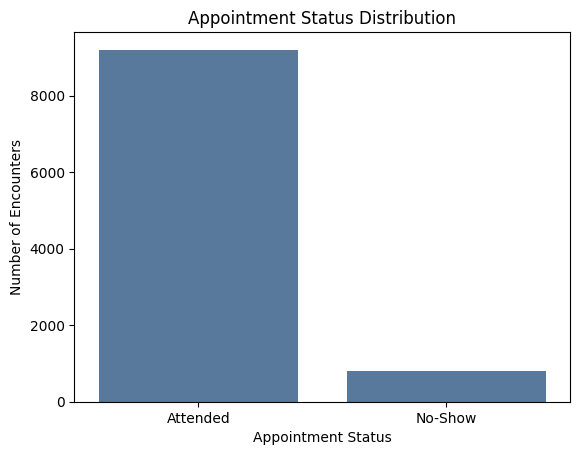

In [ ]:
sns.barplot(
    data=target_summary,
    x="Target",
    y="Count",
    color="#4C78A8"
)

plt.title("Appointment Status Distribution")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Encounters")
plt.show()

In [ ]:
ml_data.to_csv(
    "/content/Healthcare_No_Show_Model_Data.csv",
    index=False
)

In [ ]:
encounters.to_csv(
    "/content/Fact_Encounters.csv",
    index=False
)

providers.to_csv(
    "/content/Dim_Providers.csv",
    index=False
)

facilities.to_csv(
    "/content/Dim_Facilities.csv",
    index=False
)

diagnosis.to_csv(
    "/content/Dim_Diagnosis.csv",
    index=False
)

In [ ]:
files.download(
    "/content/Healthcare_No_Show_Model_Data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/Fact_Encounters.csv")
files.download("/content/Dim_Providers.csv")
files.download("/content/Dim_Facilities.csv")
files.download("/content/Dim_Diagnosis.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
validation_results = {
    "Encounter rows": len(encounters),
    "Unique Encounter IDs": encounters["Encounter_ID"].nunique(),
    "Duplicate Encounter IDs": encounters["Encounter_ID"].duplicated().sum(),
    "Missing targets": encounters["No_Show_Target"].isnull().sum(),
    "No-show count": int(encounters["No_Show_Target"].sum()),
    "No-show rate": round(
        encounters["No_Show_Target"].mean() * 100,
        2
    ),
    "Minimum date": encounters["Encounter_Date"].min(),
    "Maximum date": encounters["Encounter_Date"].max()
}

for check, result in validation_results.items():
    print(f"{check}: {result}")

Encounter rows: 10000
Unique Encounter IDs: 10000
Duplicate Encounter IDs: 0
Missing targets: 0
No-show count: 798
No-show rate: 7.98
Minimum date: 2022-12-31 00:00:00
Maximum date: 2025-12-27 00:00:00


In [ ]:
def convert_mixed_dates(series):
    # Create an empty datetime result
    result = pd.Series(
        pd.NaT,
        index=series.index,
        dtype="datetime64[ns]"
    )

    # Convert values to text and remove extra spaces
    cleaned = series.astype("string").str.strip()

    # Identify Excel serial numbers
    numeric_values = pd.to_numeric(
        cleaned,
        errors="coerce"
    )

    numeric_mask = numeric_values.notna()

    # Convert Excel serial numbers
    result.loc[numeric_mask] = pd.to_datetime(
        numeric_values.loc[numeric_mask],
        unit="D",
        origin="1899-12-30",
        errors="coerce"
    )

    # Convert regular text dates
    text_mask = ~numeric_mask & cleaned.notna()

    result.loc[text_mask] = pd.to_datetime(
        cleaned.loc[text_mask],
        format="mixed",
        errors="coerce"
    )

    return result

In [ ]:
encounters["Encounter_Date"] = convert_mixed_dates(
    encounters["Encounter_Date"]
)

providers["Start_Date"] = convert_mixed_dates(
    providers["Start_Date"]
)

facilities["Open_Date"] = convert_mixed_dates(
    facilities["Open_Date"]
)

In [ ]:
print("Encounter date type:")
print(encounters["Encounter_Date"].dtype)

print("\nEncounter date range:")
print("Minimum:", encounters["Encounter_Date"].min())
print("Maximum:", encounters["Encounter_Date"].max())

print("\nMissing or invalid dates:")
print(
    encounters["Encounter_Date"]
    .isna()
    .sum()
)

Encounter date type:
datetime64[ns]

Encounter date range:
Minimum: 2022-12-31 00:00:00
Maximum: 2025-12-27 00:00:00

Missing or invalid dates:
501


In [ ]:
display(
    encounters[
        ["Encounter_ID", "Encounter_Date"]
    ].head(10)
)

,Encounter_ID,Encounter_Date
0,ENC-000001,2025-12-14
1,ENC-000002,2024-09-16
2,ENC-000003,2025-11-30
3,ENC-000004,2024-11-04
4,ENC-000005,2024-03-18
5,ENC-000006,2024-04-23
6,ENC-000007,2024-08-12
7,ENC-000008,2023-07-23
8,ENC-000009,2024-06-23
9,ENC-000010,2024-04-07


In [ ]:
model_features = [
    "Age",
    "Sex",
    "Race_Ethnicity",
    "Facility_ID",
    "Provider_ID",
    "Visit_Type",
    "Visit_Mode",
    "Primary_Diagnosis_Code",
    "Payer",
    "Scheduled_Minutes",
    "Transportation_Barrier",
    "Food_Insecurity_Flag",
    "Year",
    "Quarter_Number",
    "Month_Number",
    "Day_of_Week_Number",
    "Is_Weekend"
]

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files

uploaded = files.upload()

Saving Healthcare_No_Show_Model_Data.csv to Healthcare_No_Show_Model_Data.csv


In [ ]:
ml_data = pd.read_csv(
    "/content/Healthcare_No_Show_Model_Data.csv"
)

print("Dataset loaded successfully.")
print("Shape:", ml_data.shape)

display(ml_data.head())

Dataset loaded successfully.
Shape: (10000, 19)


,Age,Sex,Race_Ethnicity,Facility_ID,Provider_ID,Visit_Type,Visit_Mode,Primary_Diagnosis_Code,Payer,Scheduled_Minutes,Transportation_Barrier,Food_Insecurity_Flag,Year,Quarter_Number,Month_Number,Day_of_Week_Number,Is_Weekend,No_Show_Target,Synthetic_Patient_ID
0,70.0,MALE,HISPANIC OR LATINO,FAC-005,PRV-0105,URGENT CARE,HOME VISIT,F41.9,MEDICAID,60,NO,NO,2025.0,4.0,12.0,6.0,1,0,PAT-000926
1,25.0,UNKNOWN,UNKNOWN,FAC-018,PRV-0115,PREVENTIVE VISIT,TELEHEALTH,F32.A,MEDICAID,20,YES,NO,2024.0,3.0,9.0,0.0,0,0,PAT-000740
2,77.0,FEMALE,UNKNOWN,FAC-006,PRV-0093,PREVENTIVE VISIT,TELEHEALTH,Z00.00,MEDICARE,30,NO,NO,2025.0,4.0,11.0,6.0,1,0,PAT-001302
3,62.0,MALE,WHITE,FAC-004,PRV-0110,PRIMARY CARE,IN PERSON,J06.9,OTHER,30,NO,NO,2024.0,4.0,11.0,0.0,0,0,PAT-002478
4,53.0,FEMALE,HISPANIC OR LATINO,FAC-014,PRV-0023,URGENT CARE,HOME VISIT,Z00.00,CHIP,15,NO,NO,2024.0,1.0,3.0,0.0,0,0,PAT-000592


In [ ]:
print(ml_data.columns.tolist())

['Age', 'Sex', 'Race_Ethnicity', 'Facility_ID', 'Provider_ID', 'Visit_Type', 'Visit_Mode', 'Primary_Diagnosis_Code', 'Payer', 'Scheduled_Minutes', 'Transportation_Barrier', 'Food_Insecurity_Flag', 'Year', 'Quarter_Number', 'Month_Number', 'Day_of_Week_Number', 'Is_Weekend', 'No_Show_Target', 'Synthetic_Patient_ID']


In [ ]:
required_columns = [
    "Encounter_ID",
    "Synthetic_Patient_ID",
    "Age",
    "Sex",
    "Race_Ethnicity",
    "Facility_ID",
    "Provider_ID",
    "Visit_Type",
    "Visit_Mode",
    "Primary_Diagnosis_Code",
    "Payer",
    "Scheduled_Minutes",
    "Transportation_Barrier",
    "Food_Insecurity_Flag",
    "Year",
    "Quarter_Number",
    "Month_Number",
    "Day_of_Week_Number",
    "Is_Weekend",
    "No_Show_Target"
]

missing_columns = [
    column
    for column in required_columns
    if column not in ml_data.columns
]

print("Missing columns:", missing_columns)

Missing columns: ['Encounter_ID']


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Healthcare_Dataset.xlsx to Healthcare_Dataset.xlsx


In [ ]:
import pandas as pd

original_encounters = pd.read_excel(
    "/content/Healthcare_Dataset.xlsx",
    sheet_name="Raw_Encounters"
)

print("Original rows:", len(original_encounters))

display(
    original_encounters[
        [
            "Encounter_ID",
            "Synthetic_Patient_ID"
        ]
    ].head()
)

Original rows: 10018


,Encounter_ID,Synthetic_Patient_ID
0,ENC-000001,PAT-000926
1,ENC-000002,PAT-000740
2,ENC-000003,PAT-001302
3,ENC-000004,PAT-002478
4,ENC-000005,PAT-000592


In [ ]:
original_encounters["Encounter_ID"] = (
    original_encounters["Encounter_ID"]
    .astype("string")
    .str.strip()
    .str.upper()
)

original_encounters["Synthetic_Patient_ID"] = (
    original_encounters["Synthetic_Patient_ID"]
    .astype("string")
    .str.strip()
    .str.upper()
)

original_encounters = (
    original_encounters
    .drop_duplicates(
        subset="Encounter_ID",
        keep="first"
    )
    .reset_index(drop=True)
)

ml_data = ml_data.reset_index(drop=True)

print("Unique original encounters:", len(original_encounters))
print("Prepared model records:", len(ml_data))

Unique original encounters: 10000
Prepared model records: 10000


In [ ]:
prepared_patient_ids = (
    ml_data["Synthetic_Patient_ID"]
    .astype("string")
    .str.strip()
    .str.upper()
)

original_patient_ids = (
    original_encounters["Synthetic_Patient_ID"]
    .astype("string")
    .str.strip()
    .str.upper()
)

same_length = (
    len(ml_data) == len(original_encounters)
)

matching_rows = (
    prepared_patient_ids
    == original_patient_ids
).mean() if same_length else 0

print("Same number of rows:", same_length)
print("Patient ID alignment:", matching_rows)

Same number of rows: True
Patient ID alignment: 1.0


In [ ]:
if same_length and matching_rows == 1.0:
    ml_data.insert(
        0,
        "Encounter_ID",
        original_encounters["Encounter_ID"]
    )

    print("Encounter_ID restored successfully.")
else:
    print(
        "Stop: the rows do not align. "
        "Do not attach Encounter_ID by position."
    )

Encounter_ID restored successfully.


In [ ]:
required_columns = [
    "Encounter_ID",
    "Synthetic_Patient_ID",
    "Age",
    "Sex",
    "Race_Ethnicity",
    "Facility_ID",
    "Provider_ID",
    "Visit_Type",
    "Visit_Mode",
    "Primary_Diagnosis_Code",
    "Payer",
    "Scheduled_Minutes",
    "Transportation_Barrier",
    "Food_Insecurity_Flag",
    "Year",
    "Quarter_Number",
    "Month_Number",
    "Day_of_Week_Number",
    "Is_Weekend",
    "No_Show_Target"
]

missing_columns = [
    column
    for column in required_columns
    if column not in ml_data.columns
]

print("Missing columns:", missing_columns)

Missing columns: []


In [ ]:
print(
    "Duplicate Encounter IDs:",
    ml_data["Encounter_ID"].duplicated().sum()
)

display(
    ml_data[
        [
            "Encounter_ID",
            "Synthetic_Patient_ID",
            "No_Show_Target"
        ]
    ].head()
)

Duplicate Encounter IDs: 0


,Encounter_ID,Synthetic_Patient_ID,No_Show_Target
0,ENC-000001,PAT-000926,0
1,ENC-000002,PAT-000740,0
2,ENC-000003,PAT-001302,0
3,ENC-000004,PAT-002478,0
4,ENC-000005,PAT-000592,0


In [ ]:
ml_data.to_csv(
    "/content/Healthcare_No_Show_Model_Data_Corrected.csv",
    index=False
)

In [ ]:
X = ml_data[model_features].copy()
y = ml_data["No_Show_Target"].copy()
groups = ml_data["Synthetic_Patient_ID"].copy()

In [ ]:
import pandas as pd
import numpy as np

from google.colab import files

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

# -------------------------------------------------------
# 1. Define model features
# -------------------------------------------------------

numeric_features = [
    "Age",
    "Scheduled_Minutes",
    "Year",
    "Quarter_Number",
    "Month_Number",
    "Day_of_Week_Number",
    "Is_Weekend"
]

categorical_features = [
    "Sex",
    "Race_Ethnicity",
    "Facility_ID",
    "Provider_ID",
    "Visit_Type",
    "Visit_Mode",
    "Primary_Diagnosis_Code",
    "Payer",
    "Transportation_Barrier",
    "Food_Insecurity_Flag"
]

model_features = numeric_features + categorical_features

required_columns = [
    "Encounter_ID",
    "Synthetic_Patient_ID",
    "No_Show_Target"
] + model_features

missing_columns = [
    column
    for column in required_columns
    if column not in ml_data.columns
]

if missing_columns:
    raise ValueError(
        f"Missing required columns: {missing_columns}"
    )

print("All required columns are available.")

# -------------------------------------------------------
# 2. Prepare numeric columns
# -------------------------------------------------------

for column in numeric_features:
    ml_data[column] = pd.to_numeric(
        ml_data[column],
        errors="coerce"
    )

# -------------------------------------------------------
# 3. Prepare categorical columns
# -------------------------------------------------------

for column in categorical_features:
    ml_data[column] = (
        ml_data[column]
        .astype("object")
        .replace({pd.NA: np.nan})
    )

# -------------------------------------------------------
# 4. Prepare the target
# -------------------------------------------------------

ml_data["No_Show_Target"] = pd.to_numeric(
    ml_data["No_Show_Target"],
    errors="coerce"
)

# Remove rows without a valid target
ml_data = ml_data.dropna(
    subset=["No_Show_Target"]
).reset_index(drop=True)

ml_data["No_Show_Target"] = (
    ml_data["No_Show_Target"].astype(int)
)

# -------------------------------------------------------
# 5. Define X, y, and patient groups
# -------------------------------------------------------

X = ml_data[model_features].copy()
y = ml_data["No_Show_Target"].copy()
groups = ml_data["Synthetic_Patient_ID"].copy()

print("Total model records:", len(X))
print("\nTarget distribution:")
print(y.value_counts())

# -------------------------------------------------------
# 6. Create patient-level train/test split
# -------------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_index, test_index = next(
    splitter.split(X, y, groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

print("\nTraining records:", len(X_train))
print("Testing records:", len(X_test))
print("Testing no-shows:", int(y_test.sum()))

# -------------------------------------------------------
# 7. Create preprocessing pipelines
# -------------------------------------------------------

numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(handle_unknown="ignore")
    )
])

preprocessor = ColumnTransformer([
    (
        "numeric",
        numeric_pipeline,
        numeric_features
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features
    )
])

# -------------------------------------------------------
# 8. Create and train Logistic Regression
# -------------------------------------------------------

logistic_model = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

print("\nLogistic Regression model trained successfully.")

# -------------------------------------------------------
# 9. Generate predictions
# -------------------------------------------------------

predicted_probability = (
    logistic_model.predict_proba(X_test)[:, 1]
)

predicted_status = (
    predicted_probability >= 0.50
).astype(int)

# -------------------------------------------------------
# 10. Create prediction-results table
# -------------------------------------------------------

prediction_results = ml_data.iloc[
    test_index
][
    [
        "Encounter_ID",
        "Synthetic_Patient_ID",
        "No_Show_Target"
    ]
].copy()

prediction_results["Predicted_Probability"] = (
    predicted_probability
)

prediction_results["Predicted_Status"] = (
    predicted_status
)

prediction_results["Actual_Status"] = np.where(
    prediction_results["No_Show_Target"] == 1,
    "No-Show",
    "Attended"
)

prediction_results["Predicted_Status_Label"] = np.where(
    prediction_results["Predicted_Status"] == 1,
    "Predicted No-Show",
    "Predicted Attended"
)

prediction_results["Risk_Band"] = pd.cut(
    prediction_results["Predicted_Probability"],
    bins=[0, 0.40, 0.60, 1.00],
    labels=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],
    include_lowest=True
)

# -------------------------------------------------------
# 11. Display and validate the results
# -------------------------------------------------------

print("\nPrediction file rows:", len(prediction_results))

print("\nRisk-band distribution:")
print(
    prediction_results["Risk_Band"]
    .value_counts()
)

display(prediction_results.head(10))

# -------------------------------------------------------
# 12. Save and download CSV
# -------------------------------------------------------

output_path = "/content/Model_Predictions.csv"

prediction_results.to_csv(
    output_path,
    index=False
)

print("\nCSV created successfully:")
print(output_path)

files.download(output_path)

All required columns are available.
Total model records: 10000

Target distribution:
No_Show_Target
0    9202
1     798
Name: count, dtype: int64

Training records: 8040
Testing records: 1960
Testing no-shows: 147

Logistic Regression model trained successfully.

Prediction file rows: 1960

Risk-band distribution:
Risk_Band
Medium Risk    1049
Low Risk        576
High Risk       335
Name: count, dtype: int64


,Encounter_ID,Synthetic_Patient_ID,No_Show_Target,Predicted_Probability,Predicted_Status,Actual_Status,Predicted_Status_Label,Risk_Band
3,ENC-000004,PAT-002478,0,0.543884,1,Attended,Predicted No-Show,Medium Risk
6,ENC-000007,PAT-000721,0,0.492918,0,Attended,Predicted Attended,Medium Risk
17,ENC-000018,PAT-001256,0,0.257755,0,Attended,Predicted Attended,Low Risk
19,ENC-000020,PAT-002859,0,0.659364,1,Attended,Predicted No-Show,High Risk
22,ENC-000023,PAT-001557,0,0.617077,1,Attended,Predicted No-Show,High Risk
24,ENC-000025,PAT-001905,0,0.611662,1,Attended,Predicted No-Show,High Risk
26,ENC-000027,PAT-000881,0,0.332976,0,Attended,Predicted Attended,Low Risk
35,ENC-000036,PAT-004009,0,0.282133,0,Attended,Predicted Attended,Low Risk
37,ENC-000038,PAT-001566,0,0.485333,0,Attended,Predicted Attended,Medium Risk
38,ENC-000039,PAT-002503,0,0.353314,0,Attended,Predicted Attended,Low Risk



CSV created successfully:
/content/Model_Predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>